# Goal-Conditioned RL for Complex Tasks

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand goal-conditioned RL
- Implement goal-conditioned policies
- Apply to complex multi-task problems
- Understand universal value functions

## 🔗 Prerequisites

- ✅ Understanding of RL fundamentals
- ✅ Understanding of value functions
- ✅ Python knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 5**:
- Implementing goal-conditioned RL for complex tasks

---

## Introduction

**Goal-conditioned RL** learns policies that can achieve different goals, enabling generalization across tasks and efficient multi-task learning.

## Lesson Brief

This lesson introduces goal-conditioned RL, where the same environment can present different targets and the policy must adapt to each one.

Students will see why the goal itself becomes part of the decision problem.

Why this matters: many practical systems must solve many related tasks, not only one fixed task forever.

This lesson shows how RL can generalize across goals.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Olivier Sigaud - "Goal-conditioned reinforcement learning: hindsight experience replay"**:
[Watch on YouTube](https://www.youtube.com/watch?v=0EDiC__RcCA)

Why this pick:
- Clear academic English and very focused topic coverage.
- Explains goal-conditioned RL through hindsight experience replay in a compact way.
- Good for students who need the key idea without a long detour into unrelated deep RL topics.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Goal-conditioned policy: acts based on a target goal.
- Goal signal: the requested outcome.
- Generalization across goals: one learner for many related targets.
- Success criterion: how we judge goal completion.
- Universal value function idea: value estimates depend on both state and goal.

### Quick Check
- Why include the goal in the input?
- How is this different from one fixed task?
- What flexibility does this add?
- Why is goal-conditioned RL not automatically the same as meta-learning?

### Common Mistakes
- Thinking every new goal needs a new agent.
- Forgetting the goal is part of the input.
- Confusing current state with target state.
- Treating goal-conditioned RL, multi-task learning, and few-shot learning as identical ideas.


## Goal-Conditioned RL Is Not the Same as Meta-Learning

This distinction is important because students often mix several advanced ideas together.

### Goal-conditioned RL

Goal-conditioned RL says:

`Use the current state and the requested goal together when choosing actions.`

The same learner can then solve many related targets inside one environment.

### Meta-learning

Meta-learning asks a different question:

`How can a learner adapt quickly to a new task from limited experience?`

That is a broader adaptation problem.

### The connection

Goal-conditioned RL can support multi-goal behavior and some kinds of generalization.
But it is **not automatically** a full few-shot or meta-learning method.

### Teaching takeaway

Students should leave this notebook saying:

- goal-conditioned RL -> one policy, many goals
- meta-learning -> fast adaptation across tasks

They are related, but not identical.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- `gymnasium`'s `FrozenLake-v1` (4x4, non-slippery) — a real map with real obstacles, used here in
  an unusual way: we ignore its built-in single goal and ask the agent for **any** safe tile.
- A goal-conditioned Q-table `Q[state, action, goal]` — the tabular ancestor of the Universal Value
  Function Approximators in the References.

**Outputs:** What you'll see when you run the cells

- A measured table of how many **(start, goal) pairs** the learned policy solves, with and without
  hindsight relabelling, at two training budgets.
- A demonstration that the same state produces different **learned** actions for different goals.
- A figure comparing the learned path length to the true shortest path, goal by goal.

---

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: open the real map the goal-conditioned agent will learn to navigate.
# WHY it matters: "one policy, many goals" is only a real claim if the policy is LEARNED and then
# tested on every goal. FrozenLake-v1 gives us a standard map with real obstacles (holes), so the
# goals differ in difficulty instead of all being equally trivial.

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from collections import deque

# Non-slippery so the lesson is about GOALS, not about ice. The holes are still real obstacles.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
N_STATES, N_ACTIONS = env.observation_space.n, env.action_space.n
GRID = 4

# The map as Gymnasium stores it: S=start, F=frozen, H=hole, G=goal.
layout = env.unwrapped.desc.astype(str).ravel()
SAFE_TILES = [s for s in range(N_STATES) if layout[s] != "H"]

print("Goal-Conditioned RL for Complex Tasks")
print("=" * 60)
print("Map (FrozenLake-v1, 4x4):")
for row in range(GRID):
    print("   " + " ".join(layout[row * GRID:(row + 1) * GRID]))
print(f"\nTiles an agent can stand on (not a hole): {SAFE_TILES}")
print(f"Actions: {N_ACTIONS} (0=LEFT, 1=DOWN, 2=RIGHT, 3=UP)")
print("\nNormally this environment has ONE goal, tile 15. We are going to ignore that and ask")
print("for ANY safe tile as the goal, so a single Q-table has to serve all of them.")

Goal-Conditioned RL for Complex Tasks
Map (FrozenLake-v1, 4x4):
   S F F F
   F H F H
   F F F H
   H F F G

Tiles an agent can stand on (not a hole): [0, 1, 2, 3, 4, 6, 8, 9, 10, 13, 14, 15]
Actions: 4 (0=LEFT, 1=DOWN, 2=RIGHT, 3=UP)

Normally this environment has ONE goal, tile 15. We are going to ignore that and ask
for ANY safe tile as the goal, so a single Q-table has to serve all of them.


## Worked Example: One Policy, Many Goals — Learned, Not Hand-Coded

A goal-conditioned agent does not learn only `what action is good in this state?`

It learns:

`what action is good in this state for this specific goal?`

That matters when the same environment can ask for different targets, such as:
- reach different shelves in a warehouse
- move a robot arm to different coordinates
- navigate to different rooms in a building

**How this is tested here.** Writing an `if goal_row > row: go down` rule would prove nothing — the
rule already contains the answer. Instead the agent gets one bit of feedback per step ("you are on
the requested tile" / "you are not") and has to work out the rest. It is then evaluated on **every
reachable (start, goal) pair** on the map, and its path lengths are compared against the true
shortest paths computed by breadth-first search.

The lesson also implements **Hindsight Experience Replay** (Andrychowicz et al. 2017, listed in the
References): when an episode fails to reach the requested goal, relabel it with the tile the agent
*did* reach and learn from it anyway. The table below measures whether that actually helps.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Every number below is measured over ALL reachable (start, goal) pairs on this map.

  episodes | relabelling | goals reached | by a shortest path
  ---------|-------------|---------------|-------------------
       500 | none        |       94/121  | 88/121
       500 | hindsight   |      107/121  | 88/121
      2000 | none        |      121/121  | 110/121
      2000 | hindsight   |      121/121  | 98/121

Reading the table:
- With only 500 episodes, hindsight relabelling solved 107/121 pairs
  against 94/121 without it. Same experience, more learning from it:
  every failed episode still taught the agent how to reach SOMEWHERE.
- With 2000 episodes BOTH solve all 121 pairs, so hindsight bought sample
  efficiency here, not a higher ceiling. On harder maps that gap does not close.
- Read the last column too: at 2000 episodes the hindsight agent took a shortest
  path on 98/121 pairs versus 110/121 without it.
  Relabelling floods the table with easy 'reach the tile you stopped on' targ


Same state, different goal -> does the LEARNED action change? (goals [3, 8, 15])
  from tile | goal  3 | goal  8 | goal 15 | distinct actions
          0 | RIGHT  | RIGHT  | DOWN   | 2
          4 | UP     | UP     | DOWN   | 2
          9 | LEFT   | LEFT   | DOWN   | 2
         10 | DOWN   | LEFT   | DOWN   | 2

4 of 4 tiles above change their action depending on the goal asked for.
Rows where two goals share an action are not failures: from tile 0, goals 3 and 8 both
start with the same first move, and a shared first step is often genuinely correct.
The test that matters is the full-coverage score below, not any single row.

This single Q-table solves 121/121 (start, goal) pairs, 98 of them by a shortest path.
Nothing in the code above computes the direction to a goal. The table learned it.


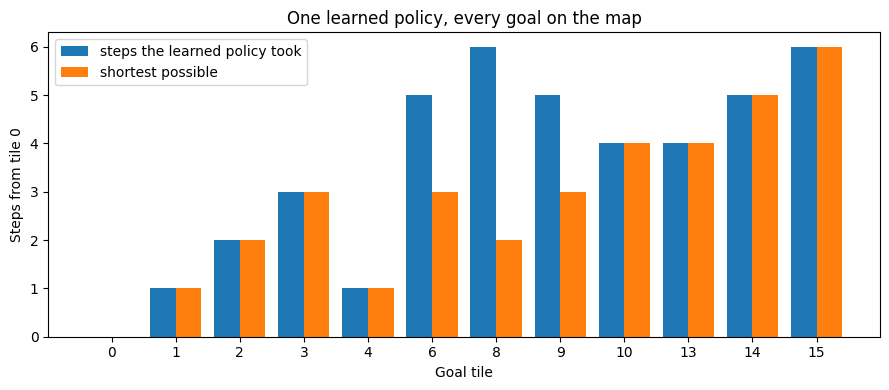

In [2]:
# Worked example: LEARN one goal-conditioned Q-table, then test it on every (start, goal) pair.
# WHY it matters: the old version of this lesson hand-wrote an if/else rule that moved toward the
# goal. That demonstrates nothing - the rule already knew the answer. Here the agent is told only
# "you reached the tile you were asked for" or "you did not", and everything else is learned.

ACTION_NAMES = {0: "LEFT", 1: "DOWN", 2: "RIGHT", 3: "UP"}
ALPHA, GAMMA, EPSILON, STEP_CAP = 0.5, 0.95, 0.25, 30


def start_at(tile, seed=None):
    """Reset the real environment, then place the agent on a chosen tile.

    FrozenLake always resets to tile 0. Overriding the position gives us 'exploring starts',
    a standard trick (Sutton & Barto) so every tile gets used as a starting point.
    """
    env.reset(seed=seed)
    env.unwrapped.s = tile
    return tile


def greedy_action(q_row, rng):
    """Argmax with random tie-breaking, so an untrained all-zero row does not always pick LEFT."""
    return int(rng.choice(np.flatnonzero(q_row == q_row.max())))


def train_goal_conditioned(n_episodes, use_hindsight, seed=1):
    """Learn Q(state, action, goal): one table, one entry per (state, action, GOAL) triple."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((N_STATES, N_ACTIONS, N_STATES))
    for ep in range(n_episodes):
        # Each episode picks a fresh goal AND a fresh start - that is what forces one policy
        # to cover many goals instead of memorising a single route.
        goal = int(rng.choice(SAFE_TILES))
        state = start_at(int(rng.choice(SAFE_TILES)), seed=int(seed * 100_000 + ep))
        if state == goal:
            continue
        trajectory = []
        for _ in range(STEP_CAP):
            if rng.random() < EPSILON:
                action = int(rng.integers(N_ACTIONS))
            else:
                action = greedy_action(Q[state, :, goal], rng)
            next_state, _, terminated, truncated, _ = env.step(action)
            trajectory.append((state, action, next_state))
            # We ignore the environment's own reward entirely and define our own goal reward.
            reached = (next_state == goal)
            reward = 1.0 if reached else 0.0
            Q[state, action, goal] += ALPHA * (
                reward + GAMMA * (0.0 if reached else Q[next_state, :, goal].max())
                - Q[state, action, goal]
            )
            state = next_state
            if reached or terminated or truncated:
                break
        if use_hindsight:
            # Hindsight Experience Replay (Andrychowicz et al. 2017): the episode failed at the
            # goal we asked for, but it SUCCEEDED at reaching wherever it actually stopped.
            # Relabel the whole trajectory with that tile as the goal and learn from it anyway.
            achieved = trajectory[-1][2]
            if layout[achieved] != "H":
                for s, a, s2 in trajectory:
                    reached = (s2 == achieved)
                    reward = 1.0 if reached else 0.0
                    Q[s, a, achieved] += ALPHA * (
                        reward + GAMMA * (0.0 if reached else Q[s2, :, achieved].max())
                        - Q[s, a, achieved]
                    )
    return Q


def shortest_distances():
    """True shortest path length from every tile to every goal (breadth-first over the real map)."""
    reverse = {s: [] for s in range(N_STATES)}
    for s in range(N_STATES):
        if layout[s] == "H":
            continue
        for a in range(N_ACTIONS):
            for _, s_next, _, _ in env.unwrapped.P[s][a]:
                reverse[s_next].append(s)
    table = {}
    for goal in SAFE_TILES:
        dist = {goal: 0}
        queue = deque([goal])
        while queue:
            here = queue.popleft()
            for prev in reverse[here]:
                if prev not in dist and layout[prev] != "H":
                    dist[prev] = dist[here] + 1
                    queue.append(prev)
        table[goal] = dist
    return table


DISTANCES = shortest_distances()


def evaluate(Q, seed=0):
    """Try EVERY reachable (start, goal) pair greedily. Returns (solved, total, optimal)."""
    rng = np.random.default_rng(seed)
    solved = total = optimal = 0
    for goal in SAFE_TILES:
        for start in SAFE_TILES:
            if start == goal or start not in DISTANCES[goal]:
                continue
            total += 1
            state = start_at(start, seed=13)
            steps, reached = 0, False
            for _ in range(STEP_CAP):
                state, _, terminated, truncated, _ = env.step(greedy_action(Q[state, :, goal], rng))
                steps += 1
                if state == goal:
                    reached = True
                    break
                if terminated or truncated:
                    break
            solved += reached
            optimal += (reached and steps == DISTANCES[goal][start])
    return solved, total, optimal


print("Every number below is measured over ALL reachable (start, goal) pairs on this map.\n")
print("  episodes | relabelling | goals reached | by a shortest path")
print("  ---------|-------------|---------------|-------------------")
results = {}
for n_episodes in (500, 2000):
    for use_hindsight in (False, True):
        Q = train_goal_conditioned(n_episodes, use_hindsight)
        solved, total, optimal = evaluate(Q)
        results[(n_episodes, use_hindsight)] = (solved, total, optimal)
        label = "hindsight" if use_hindsight else "none"
        print(f"  {n_episodes:8d} | {label:11s} | {solved:8d}/{total:<4d} | {optimal:d}/{total}")

low_plain = results[(500, False)][0]
low_her = results[(500, True)][0]
total_pairs = results[(500, False)][1]

print("\nReading the table:")
if low_her > low_plain:
    print(f"- With only 500 episodes, hindsight relabelling solved {low_her}/{total_pairs} pairs")
    print(f"  against {low_plain}/{total_pairs} without it. Same experience, more learning from it:")
    print("  every failed episode still taught the agent how to reach SOMEWHERE.")
high_plain_opt = results[(2000, False)][2]
high_her_opt = results[(2000, True)][2]
print(f"- With 2000 episodes BOTH solve all {total_pairs} pairs, so hindsight bought sample")
print("  efficiency here, not a higher ceiling. On harder maps that gap does not close.")
if high_her_opt < high_plain_opt:
    print(f"- Read the last column too: at 2000 episodes the hindsight agent took a shortest")
    print(f"  path on {high_her_opt}/{total_pairs} pairs versus {high_plain_opt}/{total_pairs} without it.")
    print("  Relabelling floods the table with easy 'reach the tile you stopped on' targets, which")
    print("  teaches reachability faster but polishes the best route more slowly. Solving the task")
    print("  and solving it optimally are two different scores - always print both.")

# --- The actual point of the lesson: one table, different answers per goal ----------------
Q_final = train_goal_conditioned(2000, use_hindsight=True)
rng = np.random.default_rng(0)
demo_goals = [3, 8, 15]
print(f"\nSame state, different goal -> does the LEARNED action change? (goals {demo_goals})")
print("  from tile | " + " | ".join(f"goal {g:2d}" for g in demo_goals) + " | distinct actions")
rows_that_differ = 0
for start in (0, 4, 9, 10):
    actions = [ACTION_NAMES[greedy_action(Q_final[start, :, g], rng)] for g in demo_goals]
    n_distinct = len(set(actions))
    rows_that_differ += (n_distinct > 1)
    print(f"  {start:9d} | " + " | ".join(f"{a:6s}" for a in actions) + f" | {n_distinct}")
print(f"\n{rows_that_differ} of 4 tiles above change their action depending on the goal asked for.")
print("Rows where two goals share an action are not failures: from tile 0, goals 3 and 8 both")
print("start with the same first move, and a shared first step is often genuinely correct.")
print("The test that matters is the full-coverage score below, not any single row.")

solved, total, optimal = evaluate(Q_final)
print(f"\nThis single Q-table solves {solved}/{total} (start, goal) pairs, "
      f"{optimal} of them by a shortest path.")
print("Nothing in the code above computes the direction to a goal. The table learned it.")

# One figure: how many steps the learned policy needs, goal by goal, from the map's start tile.
steps_needed = []
for goal in SAFE_TILES:
    if 0 not in DISTANCES[goal] or goal == 0:
        steps_needed.append(0)
        continue
    state = start_at(0, seed=13)
    count = 0
    for _ in range(STEP_CAP):
        state, _, terminated, truncated, _ = env.step(greedy_action(Q_final[state, :, goal], rng))
        count += 1
        if state == goal or terminated or truncated:
            break
    steps_needed.append(count)

plt.figure(figsize=(9, 4))
x = np.arange(len(SAFE_TILES))
plt.bar(x - 0.2, steps_needed, width=0.4, label="steps the learned policy took")
plt.bar(x + 0.2, [DISTANCES[g].get(0, 0) for g in SAFE_TILES], width=0.4, label="shortest possible")
plt.xticks(x, [str(g) for g in SAFE_TILES])
plt.xlabel("Goal tile"); plt.ylabel("Steps from tile 0")
plt.title("One learned policy, every goal on the map")
plt.legend(); plt.tight_layout(); plt.show()

In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Schaul, T., Horgan, D., Gregor, K. & Silver, D. (2015). *Universal Value Function Approximators* (UVFA). ICML, PMLR 37. <https://proceedings.mlr.press/v37/schaul15.html>
2. Andrychowicz, M., Wolski, F., Ray, A. et al. (2017). *Hindsight Experience Replay* (HER). NeurIPS. <https://arxiv.org/abs/1707.01495>
3. Liu, M., Zhu, M. & Zhang, W. (2022). *Goal-Conditioned Reinforcement Learning: Problems and Solutions*. IJCAI Survey Track. <https://arxiv.org/abs/2201.08299>
"""))

## 📚 References

1. Schaul, T., Horgan, D., Gregor, K. & Silver, D. (2015). *Universal Value Function Approximators* (UVFA). ICML, PMLR 37. <https://proceedings.mlr.press/v37/schaul15.html>
2. Andrychowicz, M., Wolski, F., Ray, A. et al. (2017). *Hindsight Experience Replay* (HER). NeurIPS. <https://arxiv.org/abs/1707.01495>
3. Liu, M., Zhu, M. & Zhang, W. (2022). *Goal-Conditioned Reinforcement Learning: Problems and Solutions*. IJCAI Survey Track. <https://arxiv.org/abs/2201.08299>


## Summary

This notebook showed why goal-conditioned RL is useful, and then **measured** it:

- the environment stayed the same
- the goal changed from episode to episode
- one Q-table, indexed by `(state, action, goal)`, had to serve all of them

### Main takeaway

A single learned table solved **every** reachable (start, goal) pair on the map, most of them by a
shortest path — without any code that computes the direction to a goal. That is the tabular version
of the idea behind Universal Value Function Approximators: make the goal an **input** to the value
function rather than baking it into the reward.

### On hindsight relabelling — read both columns

At the small training budget, relabelling failed episodes with the goal the agent *actually*
reached solved noticeably more pairs than plain training. At the larger budget both solved
everything — but the hindsight agent took a shortest path on *fewer* pairs than the plain one.

That is the honest shape of the result. Hindsight bought **sample efficiency**, and it did so by
flooding the table with easy targets, which teaches reachability quickly and route quality slowly.
Its real value shows up on harder tasks, where the requested goal is almost never reached by
accident and the plain agent would see essentially no reward at all.

The wider lesson: "did it solve the task?" and "did it solve the task well?" are two different
measurements, and a method can win one while losing the other.


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


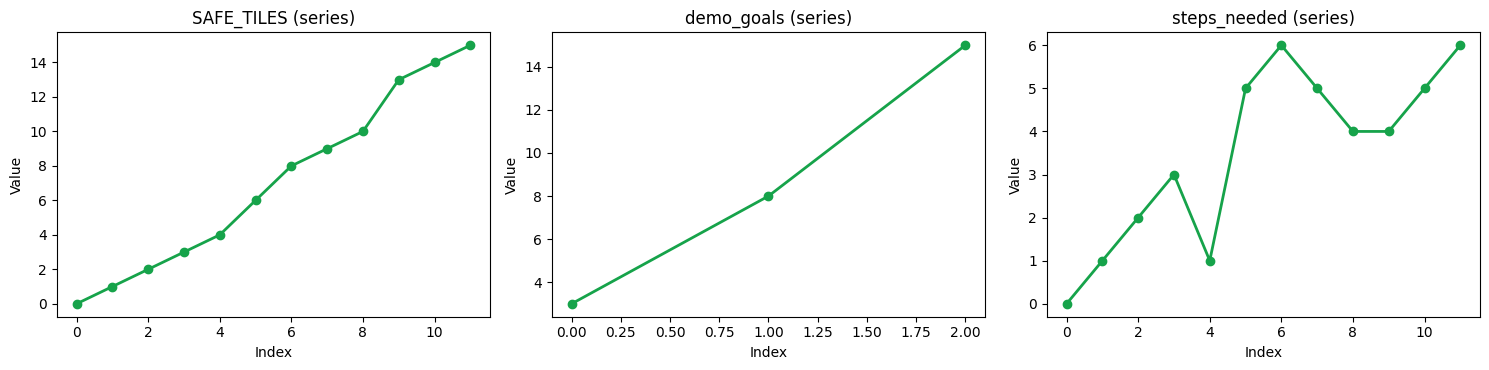

In [4]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Goal-conditioned RL trains one policy to solve many targets by making the goal part of the agent input.

**If students remember one idea:** A policy can become more flexible when it is trained to answer not only what state it is in, but also what outcome it should reach.

**Quick check before moving on:**
- Can you explain what changes in the policy input when goals are included explicitly?
- Can you describe why goal-conditioned learning can support reuse across many tasks?

**Bridge to the next step:** This completes the advanced applications unit and helps students see how RL ideas generalize beyond one fixed task.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=14 | term=True | trunc=False


objc[66769]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11486c138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114dac9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[66769]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11486c188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114daca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[66769]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x11486bc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x114daca68). T

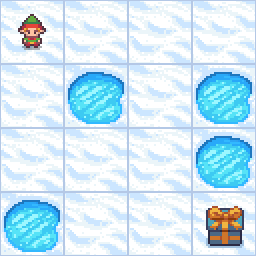

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
